In [2]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
from sklearn.preprocessing import StandardScaler

from os.path import join
import os

config_dir = "../../config"
if config_dir not in sys.path:
    sys.path.insert(0, config_dir)

from config import add_to_path, root_dir,google_folder_id,download_dir
add_to_path(join(root_dir, 'src'))
import utils.preprocessing as preprocessing
import anomaly_detection.deep_learning.AE as AE
from data_loader import load_data

Added to sys: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\Projet-recheche-INSA-anomaly-detection-librairy-1\src


In [3]:
data_dict, extracted_dir = load_data(
    file_id=google_folder_id,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data.tar",
    pattern="*.csv",
)

list_keys = list(data_dict.keys())

In [4]:
list_session = []
for s in list_keys:
    df = data_dict[s].copy()
    if preprocessing.clean_dataframe(df).shape[0] != 0:
        list_session.append(s)

len(list_session)

40

D'après l'étude faite dans anl02p1-pca on ne garde uniquement les 30 suivantes sessions.

In [5]:
# We only keep normal sessions
# Using the result of anl02p1, PCA

session_anomaly = ['T24S12-04_E-AL2706',
 'T24S12-04_E-AL2725',
 'T24S12-04_E-AL2761',
 'T24S12-04_E-AL2780',
 'T24S12-04_E-AL2819',
 'T24S12-04_E-AL2948',
 'T24S12-04_E-AL3089',
 'T24S12-04_E-AL3155',
 'T24S12-04_E-AL3597',
 'T24S12-04_E-AL3674']

clean_sessions = [
    k for k in list_session
    if os.path.splitext(os.path.basename(k))[0] not in session_anomaly
]
df_list = []

for cle in clean_sessions:
    df_temp = data_dict[cle].copy()
    df_temp = preprocessing.clean_dataframe(df_temp)
    session_name = os.path.splitext(os.path.basename(cle))[0]
    if 'session_id' not in df_temp.columns:
        df_temp['session_id'] = session_name
    df_list.append(df_temp)

df_filtered = pd.concat(df_list, ignore_index=True)


print(f"Données chargées. Dimensions : {df_filtered.shape}")
print(f"Nombre de sessions saines : {df_filtered['session_id'].nunique()}")
display(df_filtered.head())


Données chargées. Dimensions : (289405, 18)
Nombre de sessions saines : 30


,datetime,nwl1,nwl2,nwl3,nwl4,fprd1,fprd2,fprd3,fprd4,pstr1,pstr3,astrw,g2,ny,vcrf,v2,time_real,session_id
0,2024-05-03 22:49:36.502,1916.29,2035.22,2010.47,1983.84,4250.50,4300.35,7630.84,8613.12,4.17052,2.57613,0.985107,-0.180691,-0.472259,248.967,-2.387850,0.00,T24S12-04_E-AL2870
1,2024-05-03 22:49:36.512,1916.29,2036.40,2017.03,1987.99,4000.12,4255.14,7768.87,9137.16,4.42023,2.31616,0.952778,-0.275728,-0.823481,249.055,0.157031,0.01,T24S12-04_E-AL2870
2,2024-05-03 22:49:36.522,1919.14,2041.12,2013.75,1993.19,4080.10,3708.03,8209.24,9542.19,3.98324,2.46781,0.880037,-0.156931,-0.608216,249.232,-1.916580,0.02,T24S12-04_E-AL2870
3,2024-05-03 22:49:36.532,1920.09,2036.40,2013.75,1986.96,3585.15,3214.24,8666.04,9658.90,4.07688,2.51114,0.742637,-0.014376,-1.118060,249.321,-1.508140,0.03,T24S12-04_E-AL2870
4,2024-05-03 22:49:36.542,1920.09,2041.12,2020.31,1991.11,3347.52,3361.45,8725.20,9462.10,4.23295,2.26200,0.758802,-0.145052,-0.959439,249.498,-3.204730,0.04,T24S12-04_E-AL2870


Séparation en un jeu d'entrainement et un jeu de test 

In [6]:

all_sessions = df_filtered['session_id'].unique()

# random selection of 6 sessions (20% of 30)
random.seed(40)
test_sessions = random.sample(list(all_sessions), 6)
train_sessions = [s for s in all_sessions if s not in test_sessions]

print(f"Sessions d'entraînement : {train_sessions}")
print(f"Sessions de test : {test_sessions}")

df_train = df_filtered[df_filtered['session_id'].isin(train_sessions)].copy()
df_test = df_filtered[df_filtered['session_id'].isin(test_sessions)].copy()


Sessions d'entraînement : ['T24S12-04_E-AL2870', 'T24S12-04_E-AL2909', 'T24S12-04_E-AL2928', 'T24S12-04_E-AL2987', 'T24S12-04_E-AL3014', 'T24S12-04_E-AL3033', 'T24S12-04_E-AL3070', 'T24S12-04_E-AL3221', 'T24S12-04_E-AL3240', 'T24S12-04_E-AL3261', 'T24S12-04_E-AL3280', 'T24S12-04_E-AL3339', 'T24S12-04_E-AL3377', 'T24S12-04_E-AL3417', 'T24S12-04_E-AL3438', 'T24S12-04_E-AL3458', 'T24S12-04_E-AL3479', 'T24S12-04_E-AL3499', 'T24S12-04_E-AL3538', 'T24S12-04_E-AL3558', 'T24S12-04_E-AL3577', 'T24S12-04_E-AL3651', 'T24S12-04_E-AL3671', 'T24S12-04_E-AL3690']
Sessions de test : ['T24S12-04_E-AL3319', 'T24S12-04_E-AL3397', 'T24S12-04_E-AL3358', 'T24S12-04_E-AL2889', 'T24S12-04_E-AL3052', 'T24S12-04_E-AL3143']


In [7]:

features = [c for c in df_filtered.columns if c not in ['session_id', 'time_real', 'datetime']]

#Standandardization of the datasets
scaler = StandardScaler()
df_train[features] = scaler.fit_transform(df_train[features])
df_test[features] = scaler.transform(df_test[features])

In [8]:
# With overlapping of sequences (step of 1)
def create_sequences(df_input, features_list, time_steps):
    sequences_list = []
    for _, df_session in df_input.groupby('session_id'):
        values = df_session[features_list].values
        for i in range(len(values) - time_steps + 1):
            seq=values[i : (i + time_steps),:]
            sequences_list.append(seq)
    return np.array(sequences_list)

# Without overlapping
def create_sequences_no_overlap(df_input, features_list, time_steps):
    sequences_list = []
    for _, df_session in df_input.groupby('session_id'):
        values = df_session[features_list].values
        for i in range(0, len(values) - time_steps + 1, time_steps):
            seq = values[i : (i + time_steps), :]
            sequences_list.append(seq)
            
    return np.array(sequences_list)


In [9]:
TIME_STEPS = 10 

x_train = create_sequences(df_train, features, TIME_STEPS)
x_test = create_sequences(df_test, features, TIME_STEPS)

print(f"Shape x_train : {x_train.shape}")
print(f"Shape x_test : {x_test.shape}")

Shape x_train : (231831, 10, 15)
Shape x_test : (57304, 10, 15)


In [10]:
model_dnn = AE.build_dnn_ae(time_steps=10, nb_features=15)
model_dnn.summary()

Model: "DNN_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         9,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 150)            │         9,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 10, 15)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,678 (96.40 KB)

 Trainable params: 24,678 (96.40 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Début entrainement")

history = model_dnn.fit(
    x=x_train, 
    y=x_train,            
    epochs=50,            
    batch_size=256,       
    validation_split=0.3,  
    callbacks=[early_stop]
)

print("Entraînement terminé ")

Début entrainement
Epoch 1/50
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.1087 - val_loss: 0.0427
Epoch 2/50
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0349 - val_loss: 0.0363
Epoch 3/50
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0305 - val_loss: 0.0330
Epoch 4/50
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0281 - val_loss: 0.0312
Epoch 5/50
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0267 - val_loss: 0.0293
Epoch 6/50
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0255 - val_loss: 0.0279
Epoch 7/50
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0245 - val_loss: 0.0269
Epoch 8/50
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0238 - val_loss: 0.0270
Epoch 9/50
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0232 - val_loss: 0.0256
Epoch 10/50
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0227 - val_loss: 0.0251
Epoch 11/50
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0224 - val_loss: 0.0249
Epoch 12/50
634/634 ━━━━━━━━━━━━━

In [12]:
# 1. Prédiction sur les données d'entraînement 
x_train_pred = model_dnn.predict(x_train)

# 2. Erreur MAE par capteur (On fait la moyenne sur le temps, mais on garde les 15 capteurs)
# axis=1 correspond à la dimension du temps (time_steps).
# Le résultat aura pour dimension (Nombre_de_sequences, 15)
erreurs_par_capteur = np.mean(np.abs(x_train_pred - x_train), axis=1)

# 3. Calcul de la moyenne (mu) et de l'écart-type (sigma) pour CHAQUE capteur
mu = np.mean(erreurs_par_capteur, axis=0)
sigma = np.std(erreurs_par_capteur, axis=0)


# Un beta de 3 équivaut à la règle statistique des 99.7% de confiance
BETA = 3

# 5. Calcul des seuils dynamiques pour les 15 capteurs
seuils_dynamiques = mu + BETA * sigma

# --- AFFICHAGE POUR TON RAPPORT ---
print(f"\nSeuils calculés pour chaque capteur (Beta = {BETA}) :")
for i, col in enumerate(features[:15]): # Assure-toi que "features" contient bien le nom de tes colonnes
    print(f" - {col} : Seuil = {seuils_dynamiques[i]:.4f} (Mu: {mu[i]:.4f}, Sigma: {sigma[i]:.4f})")

7245/7245 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step

Seuils calculés pour chaque capteur (Beta = 3) :
 - nwl1 : Seuil = 0.0657 (Mu: 0.0164, Sigma: 0.0164)
 - nwl2 : Seuil = 0.0633 (Mu: 0.0170, Sigma: 0.0154)
 - nwl3 : Seuil = 0.0604 (Mu: 0.0178, Sigma: 0.0142)
 - nwl4 : Seuil = 0.0617 (Mu: 0.0188, Sigma: 0.0143)
 - fprd1 : Seuil = 0.3252 (Mu: 0.1140, Sigma: 0.0704)
 - fprd2 : Seuil = 0.3212 (Mu: 0.1139, Sigma: 0.0691)
 - fprd3 : Seuil = 0.3345 (Mu: 0.1078, Sigma: 0.0756)
 - fprd4 : Seuil = 0.3042 (Mu: 0.1047, Sigma: 0.0665)
 - pstr1 : Seuil = 0.2981 (Mu: 0.0926, Sigma: 0.0685)
 - pstr3 : Seuil = 0.2782 (Mu: 0.0888, Sigma: 0.0631)
 - astrw : Seuil = 0.1209 (Mu: 0.0294, Sigma: 0.0305)
 - g2 : Seuil = 0.1845 (Mu: 0.0630, Sigma: 0.0405)
 - ny : Seuil = 0.1725 (Mu: 0.0528, Sigma: 0.0399)
 - vcrf : Seuil = 0.0676 (Mu: 0.0173, Sigma: 0.0168)
 - v2 : Seuil = 0.5194 (Mu: 0.2297, Sigma: 0.0966)


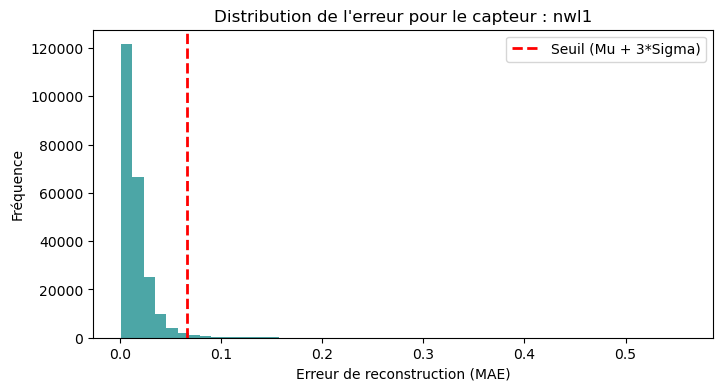

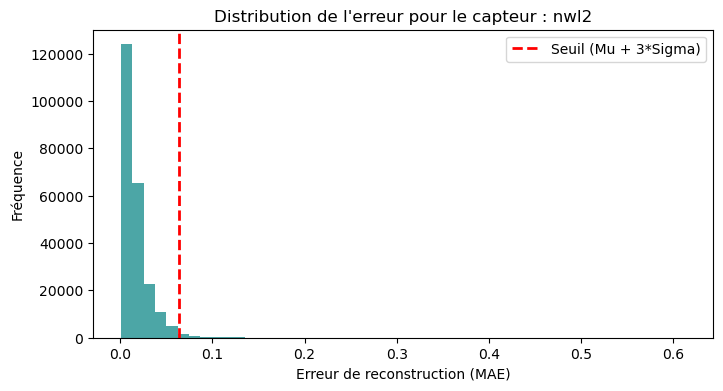

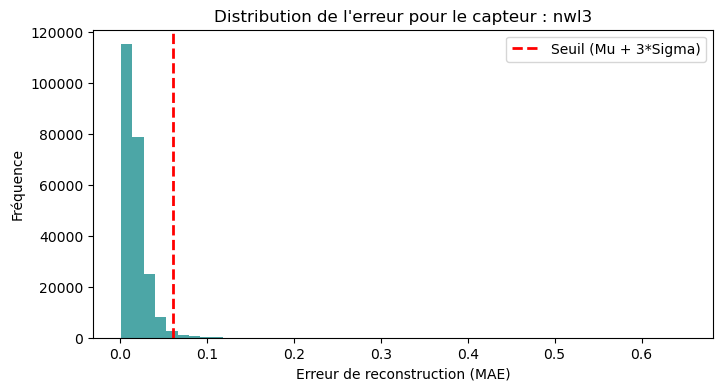

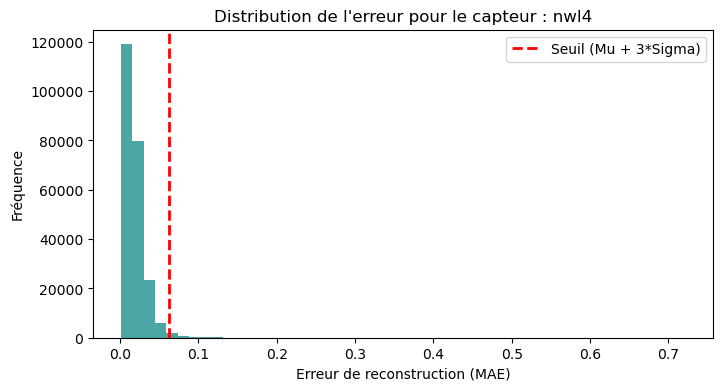

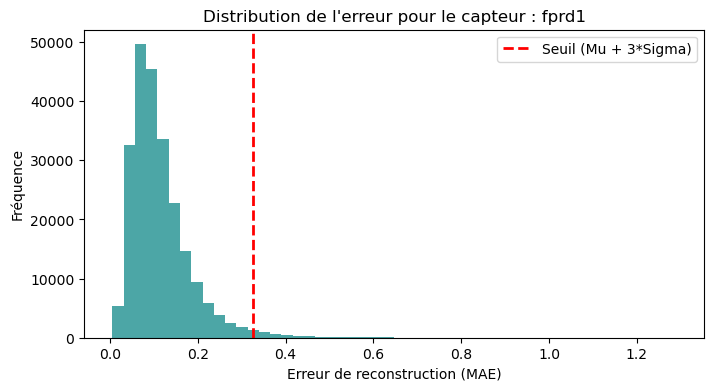

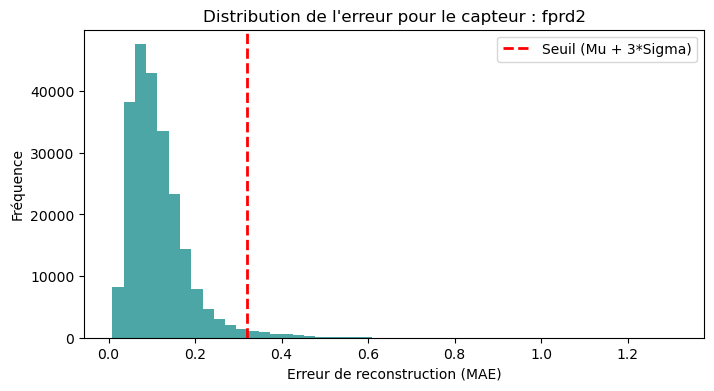

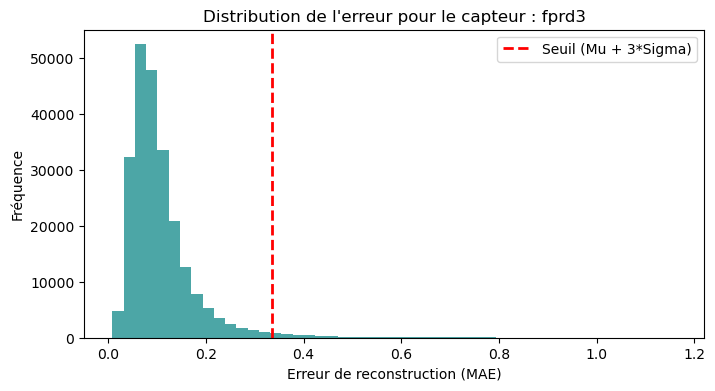

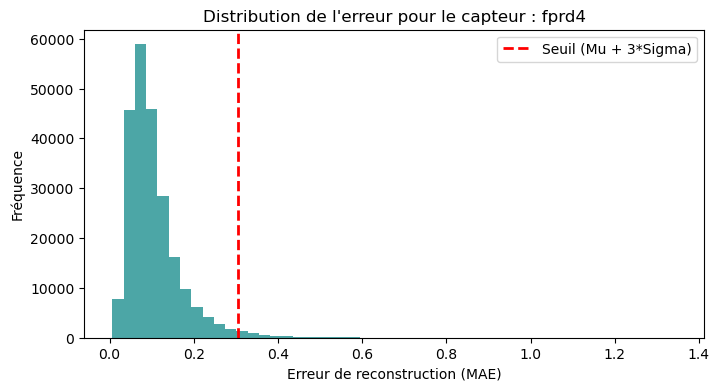

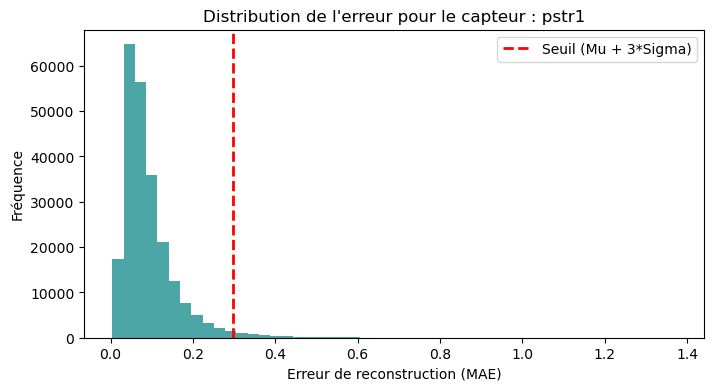

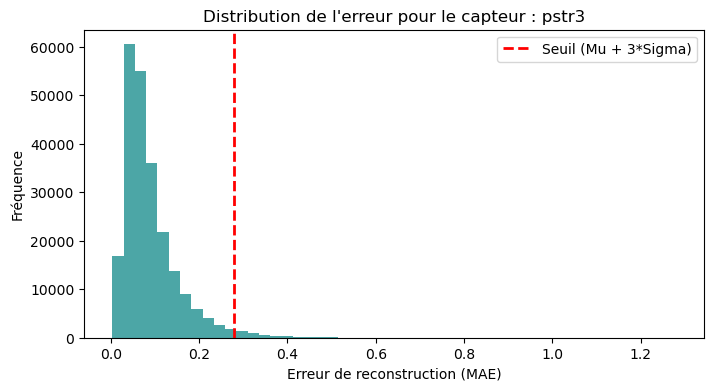

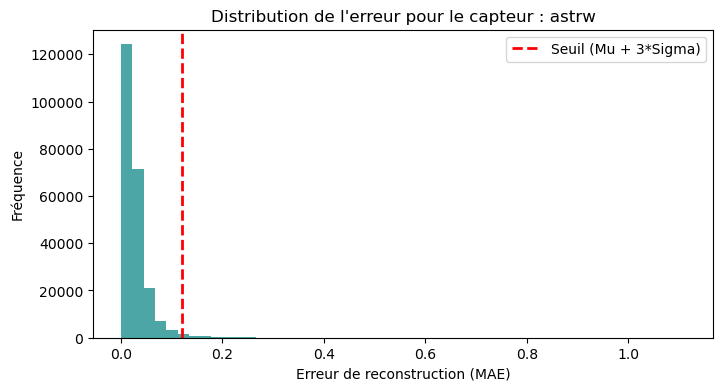

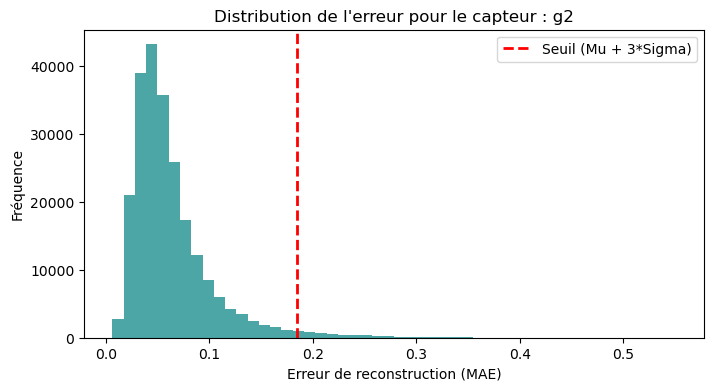

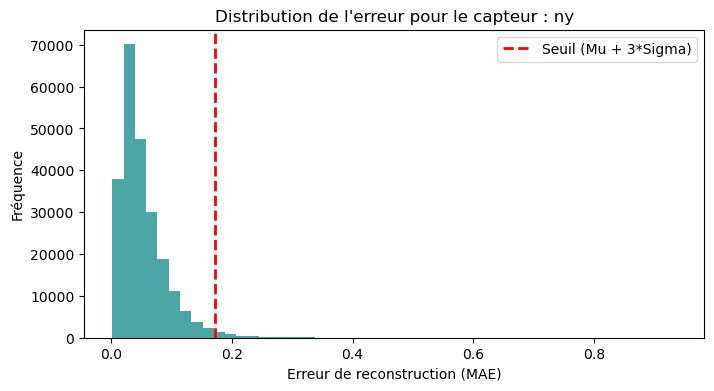

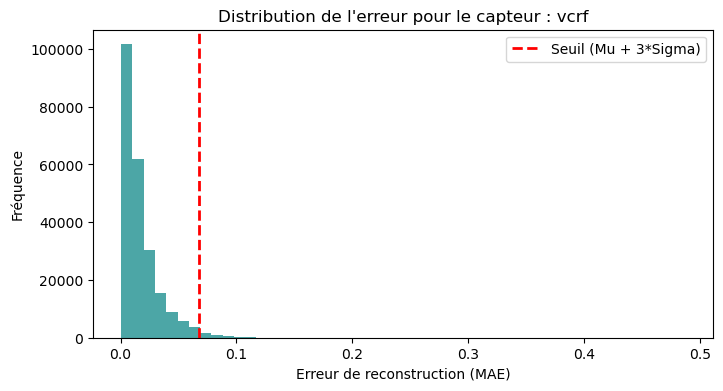

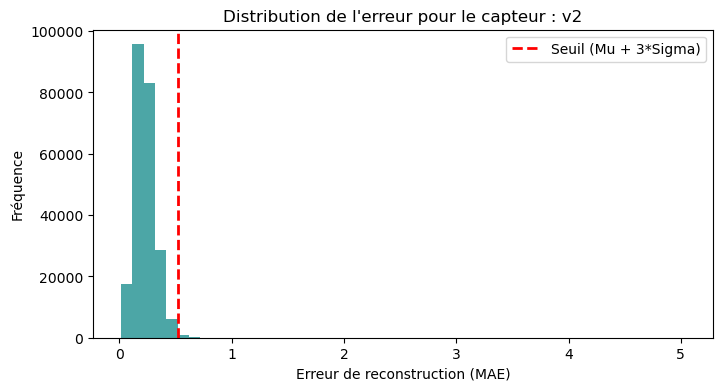

In [15]:
# Visualisation : On affiche la distribution du premier capteur pour vérifier
for capteur_idx in range(15):
    plt.figure(figsize=(8, 4))
    plt.hist(erreurs_par_capteur[:, capteur_idx], bins=50, color='teal', alpha=0.7)
    plt.axvline(seuils_dynamiques[capteur_idx], color='red', linestyle='dashed', linewidth=2, label=f'Seuil (Mu + {BETA}*Sigma)')
    plt.title(f"Distribution de l'erreur pour le capteur : {features[capteur_idx]}")
    plt.xlabel("Erreur de reconstruction (MAE)")
    plt.ylabel("Fréquence")
    plt.legend()
    plt.show()

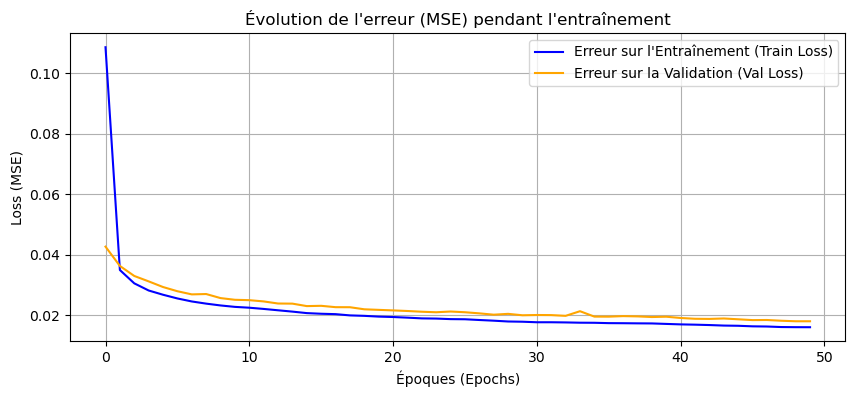

In [17]:
# VISUALISATION : Courbes d'apprentissage (Loss)
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Erreur sur l\'Entraînement (Train Loss)', color='blue')
plt.plot(history.history['val_loss'], label='Erreur sur la Validation (Val Loss)', color='orange')
plt.title('Évolution de l\'erreur (MSE) pendant l\'entraînement')
plt.xlabel('Époques (Epochs)')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


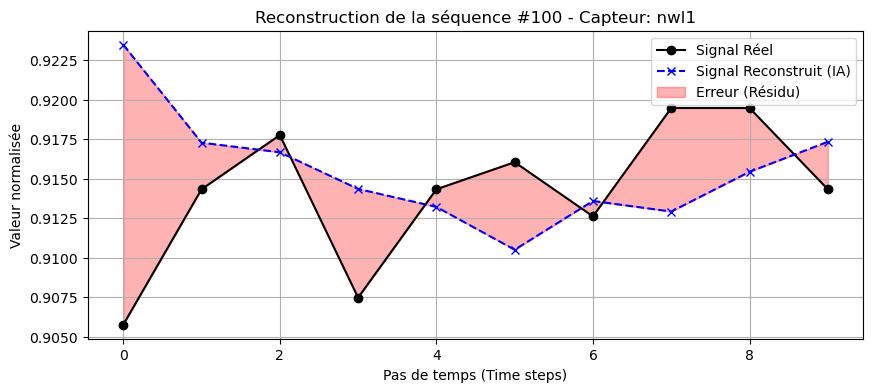

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


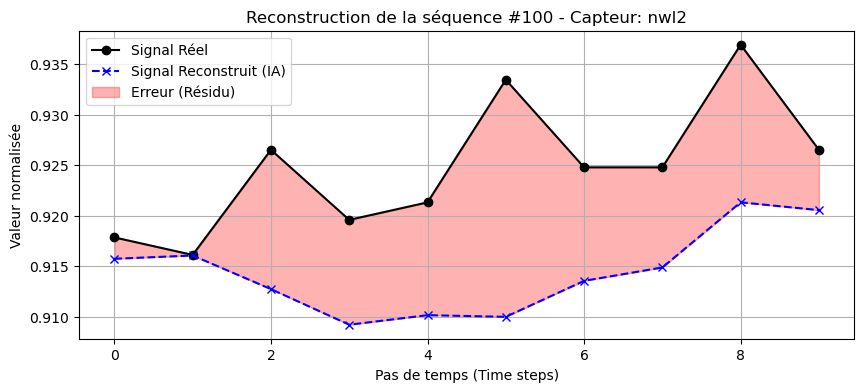

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


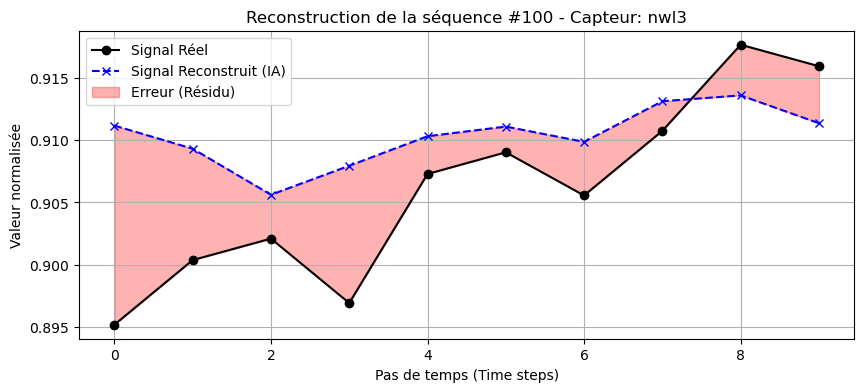

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


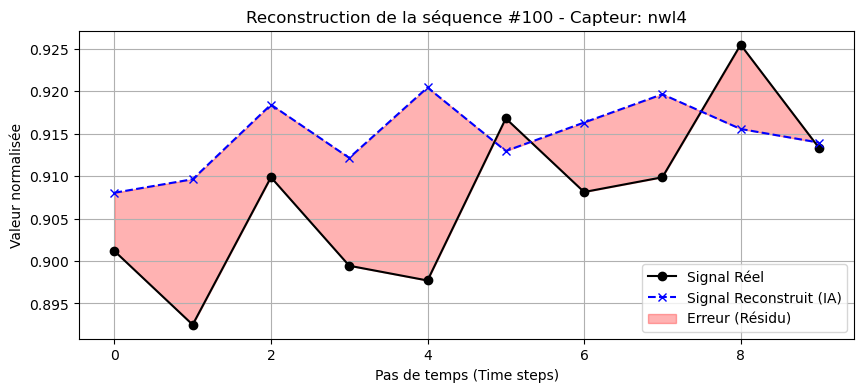

In [27]:
# VISUALISATION 2 : Original serie vs Rebuilt (avec zone d'erreur) zoom on small sequences
# A random sequence of the test dataset
sequence_idx = 100
#list of the sensor sensors 
for capteur_idx in range(4): 

# On isole la vraie séquence (taille: 10)
    vraie_sequence = x_test[sequence_idx, :, capteur_idx]



    sequence_3d = x_test[sequence_idx][np.newaxis, :, :]
    sequence_reconstruite = model_dnn.predict(sequence_3d)[0, :, capteur_idx]

    plt.figure(figsize=(10, 4))
    temps = np.arange(len(vraie_sequence))

    plt.plot(temps, vraie_sequence, label='Signal Réel', color='black', marker='o')
    plt.plot(temps, sequence_reconstruite, label='Signal Reconstruit (IA)', color='blue', linestyle='dashed', marker='x')

    # On colorie l'espace entre les deux courbes en rouge (c'est notre erreur de reconstruction !)
    plt.fill_between(temps, vraie_sequence, sequence_reconstruite, color='red', alpha=0.3, label='Erreur (Résidu)')

    plt.title(f"Reconstruction de la séquence #{sequence_idx} - Capteur: {features[capteur_idx]}")
    plt.xlabel("Pas de temps (Time steps)")
    plt.ylabel("Valeur normalisée")
    plt.legend()
    plt.grid(True)
    plt.show()

303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


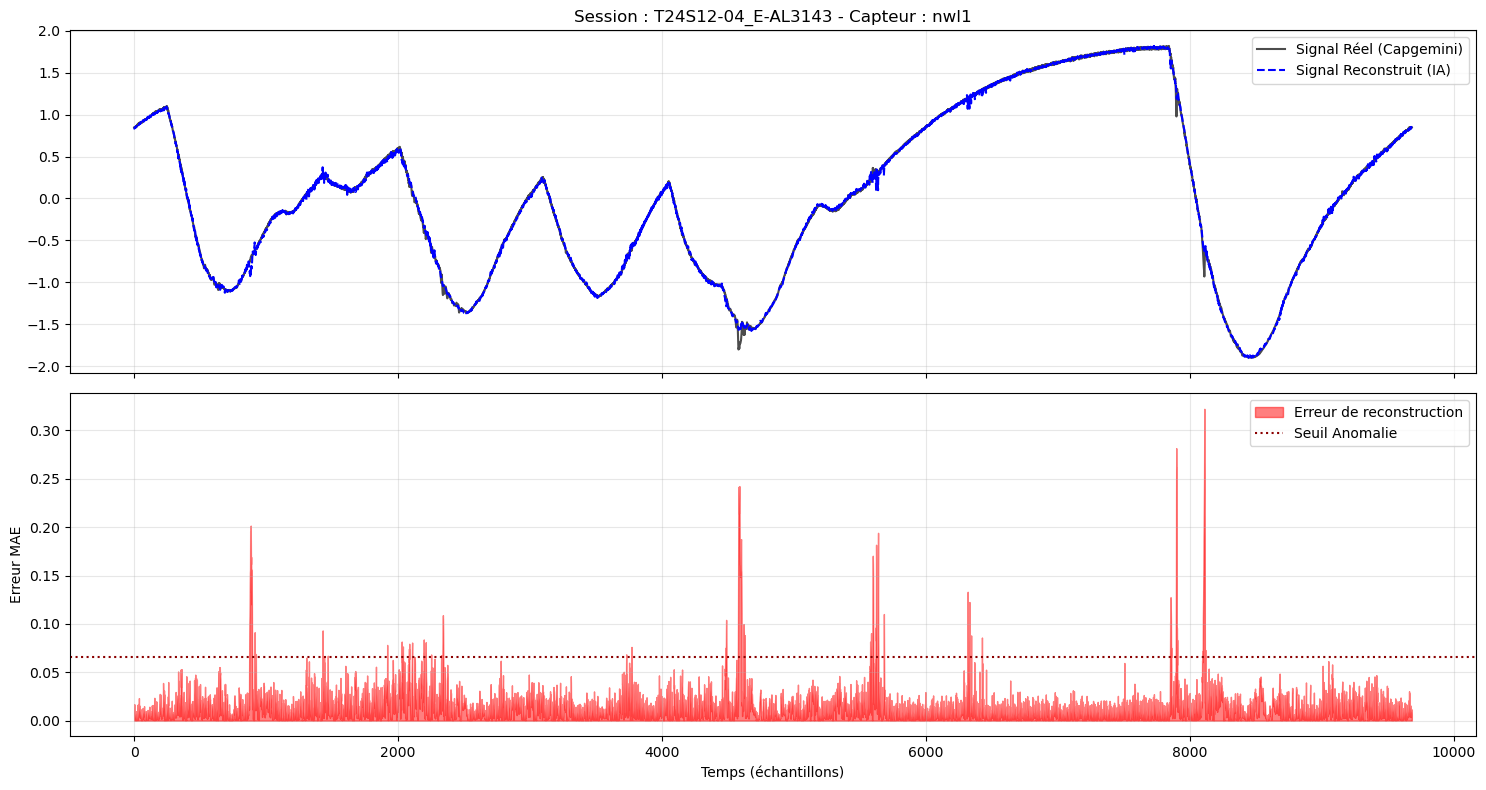

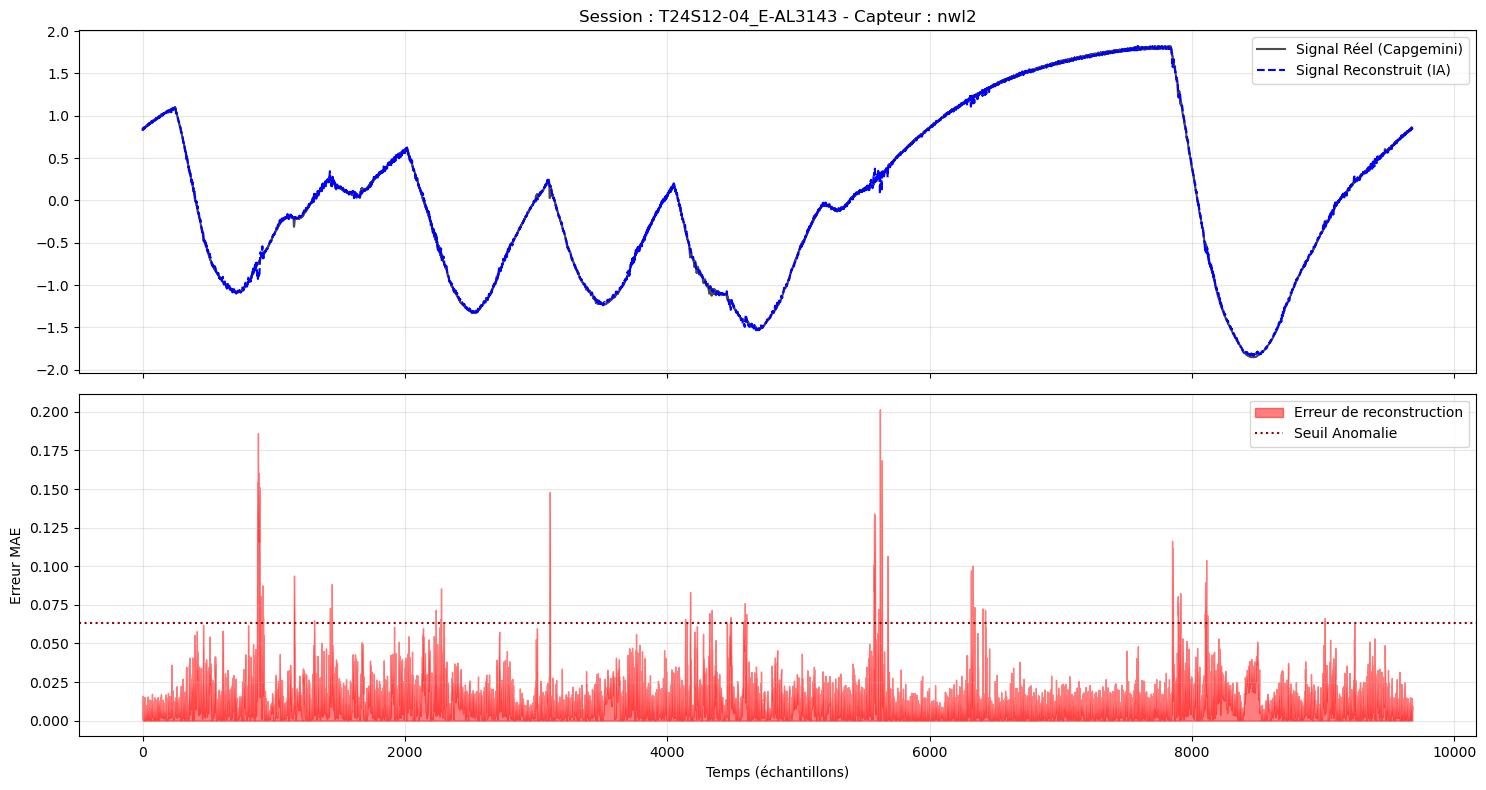

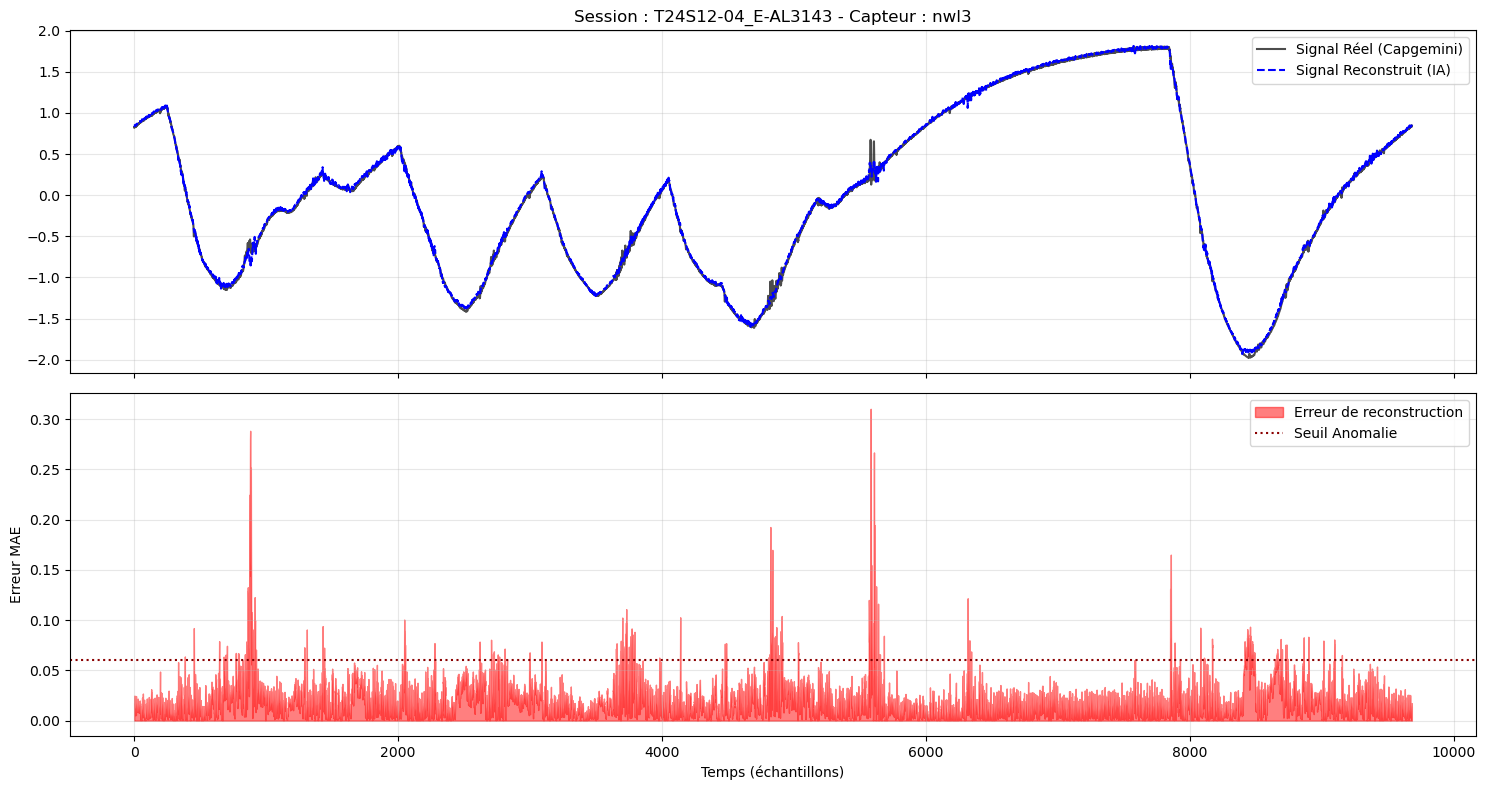

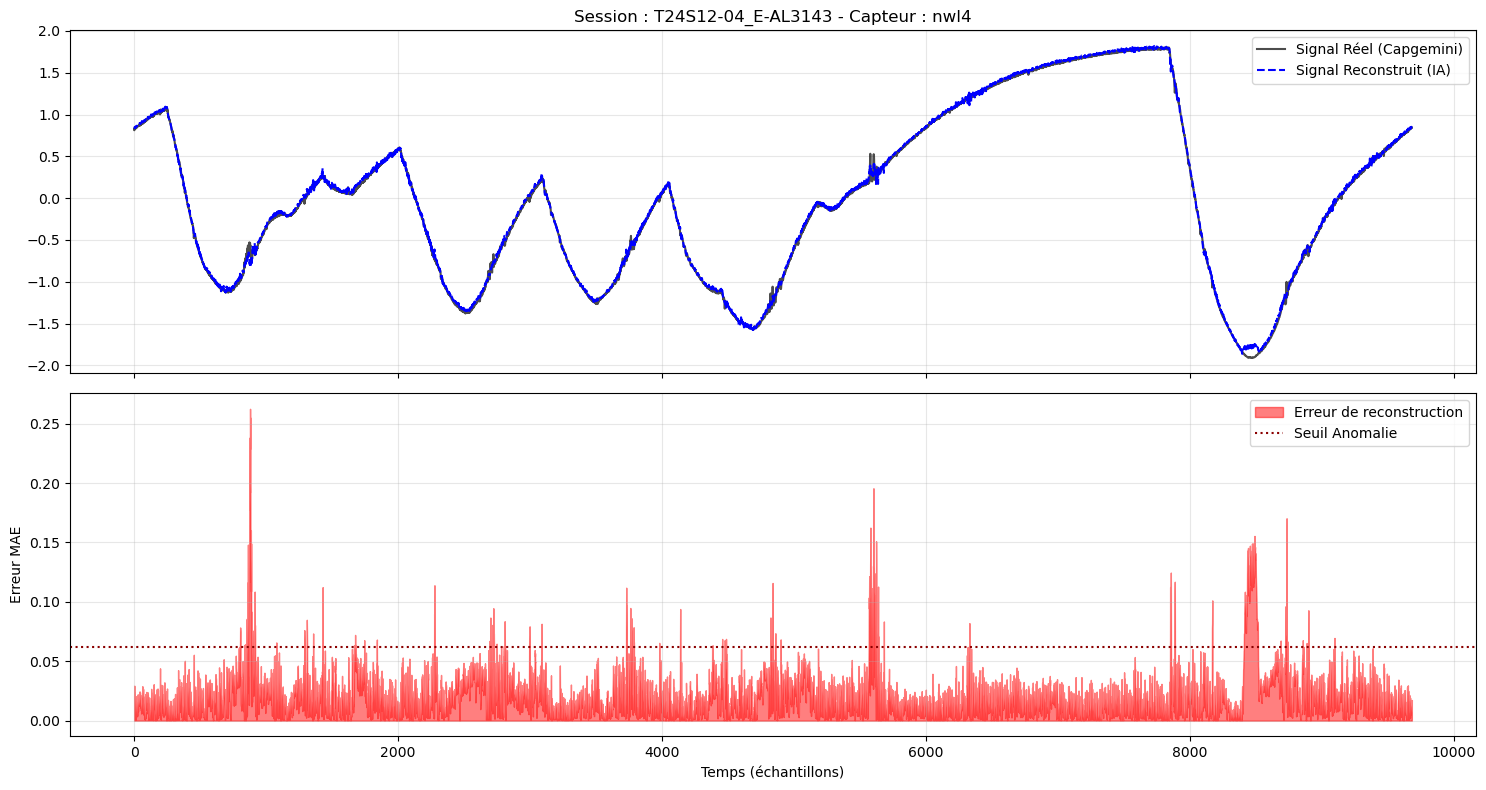

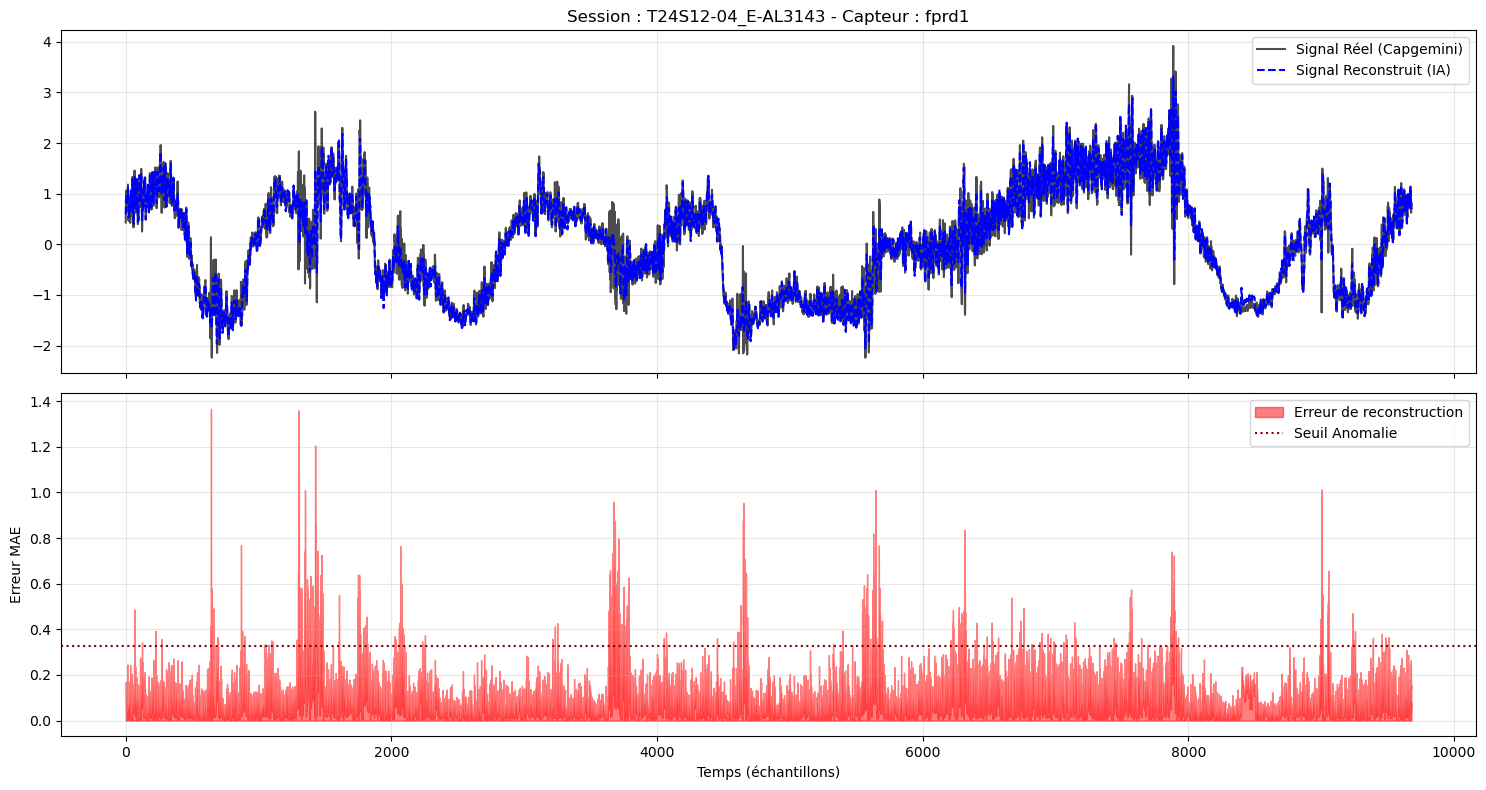

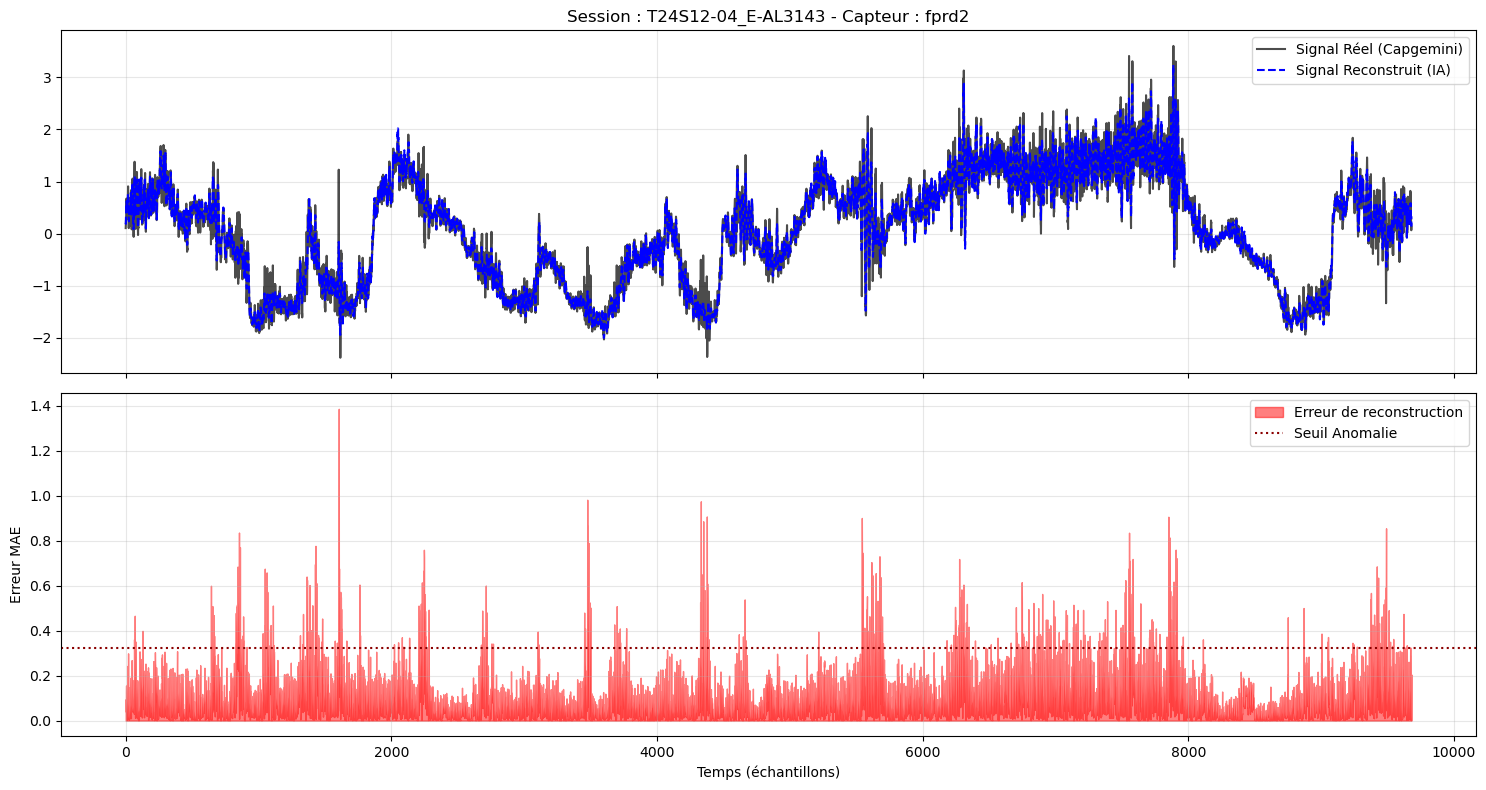

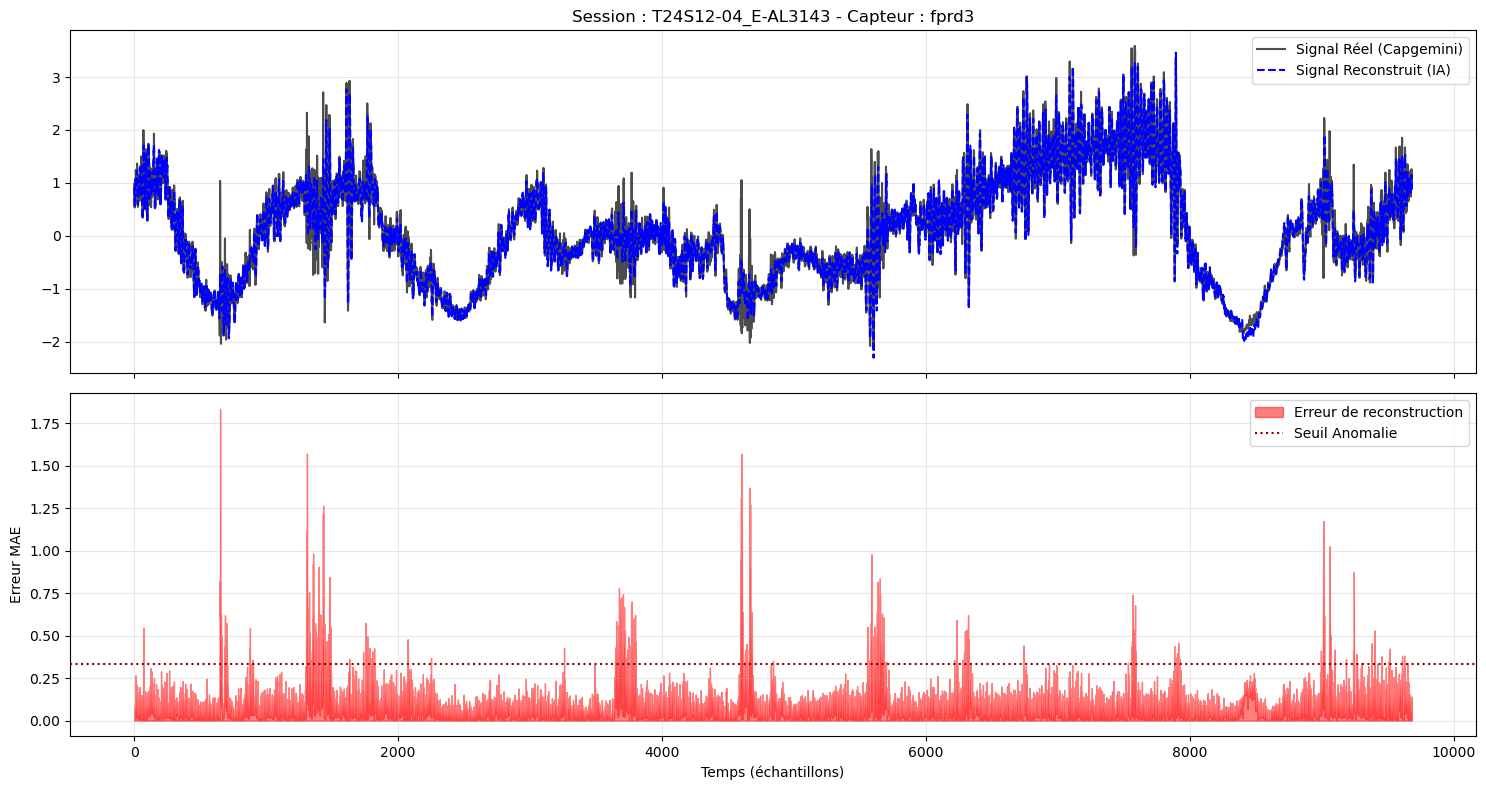

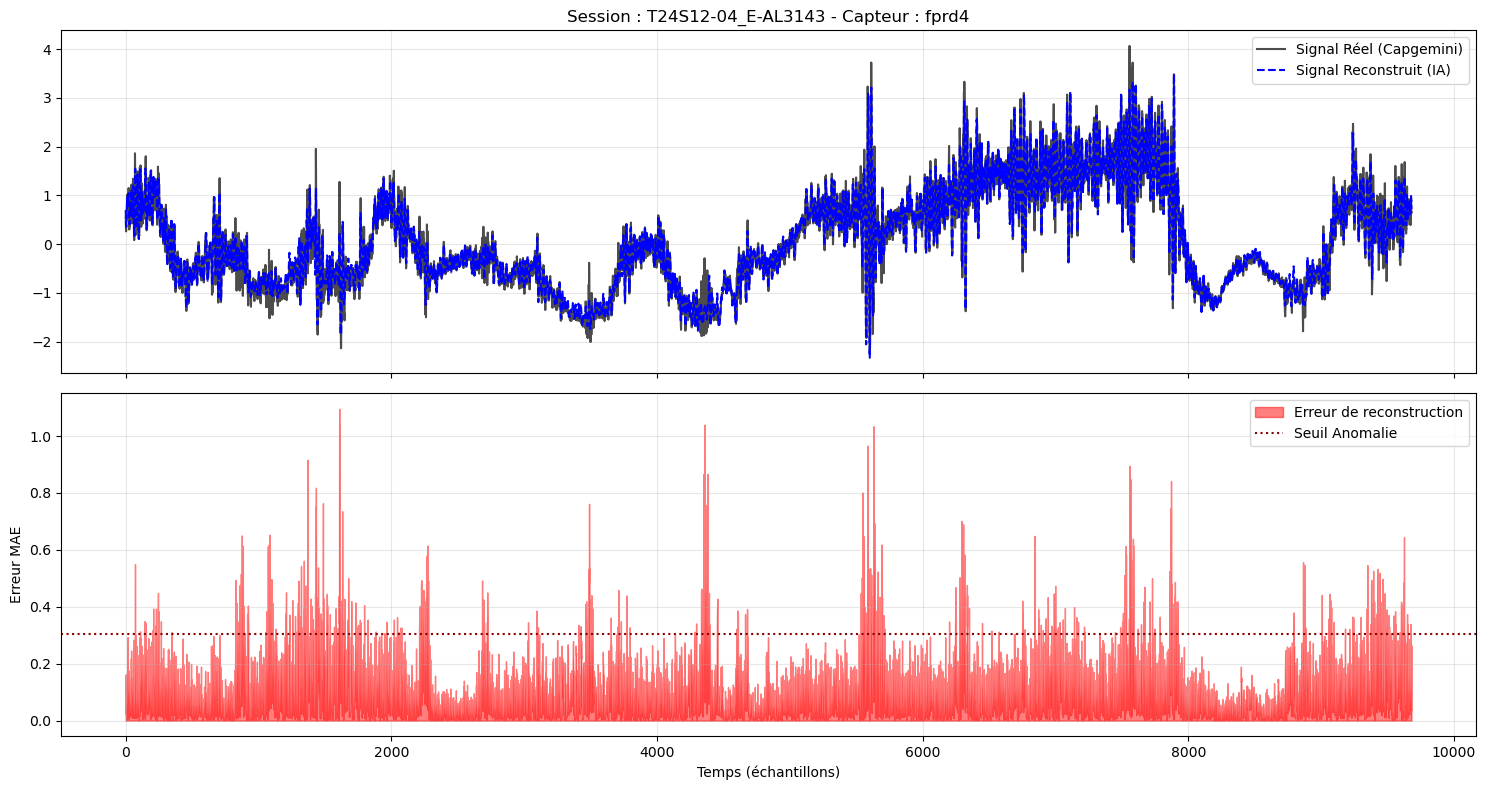

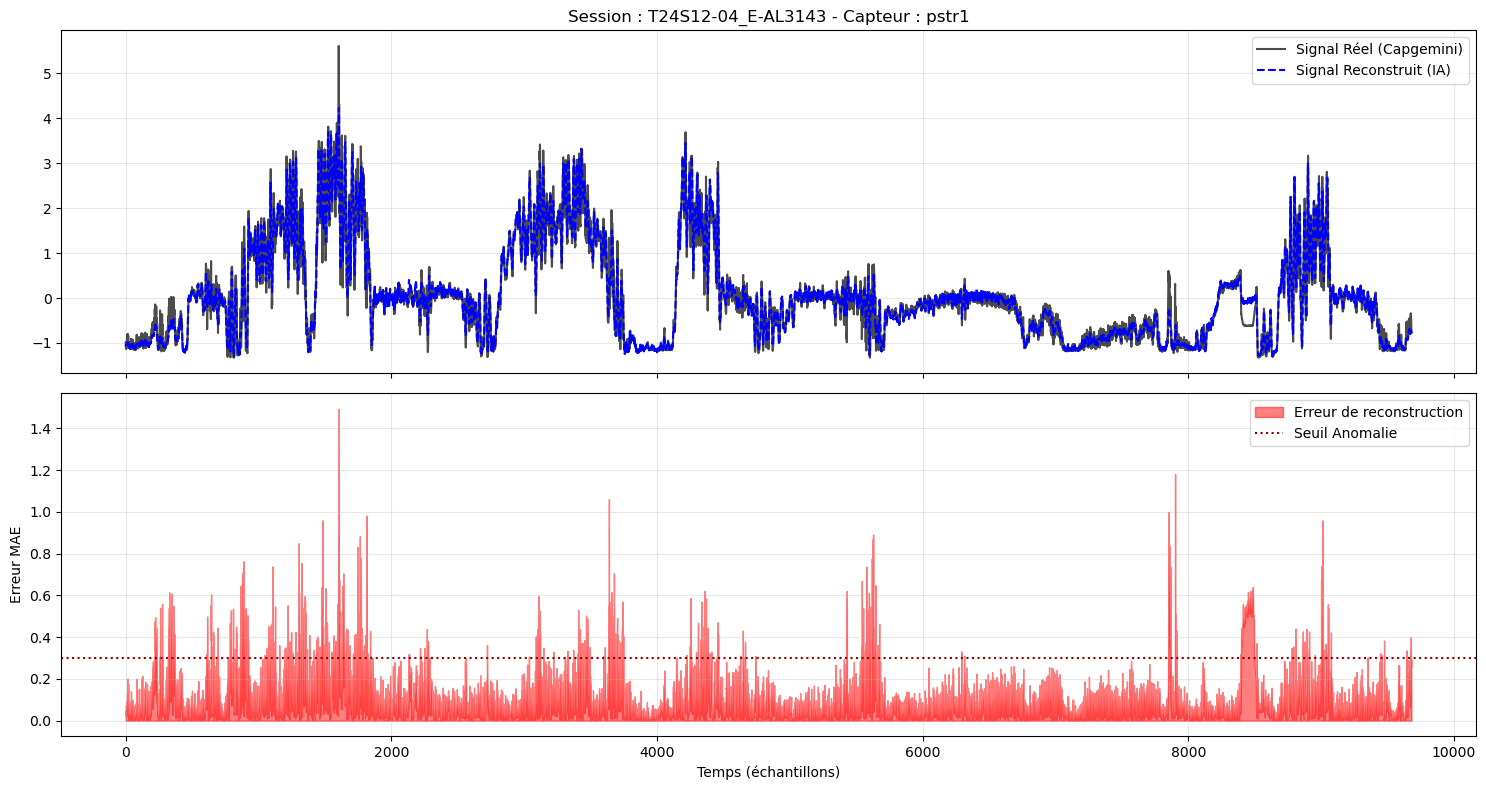

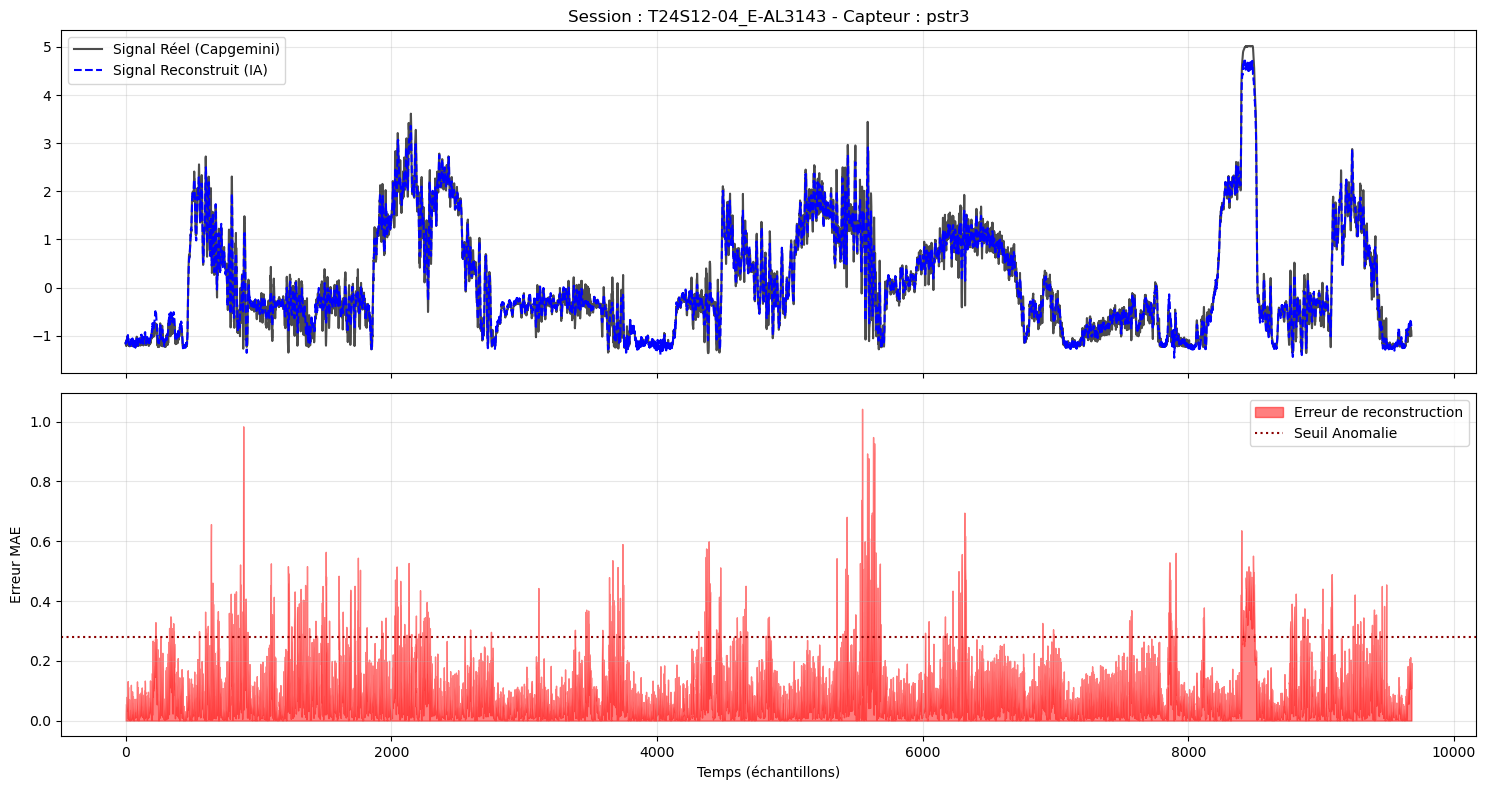

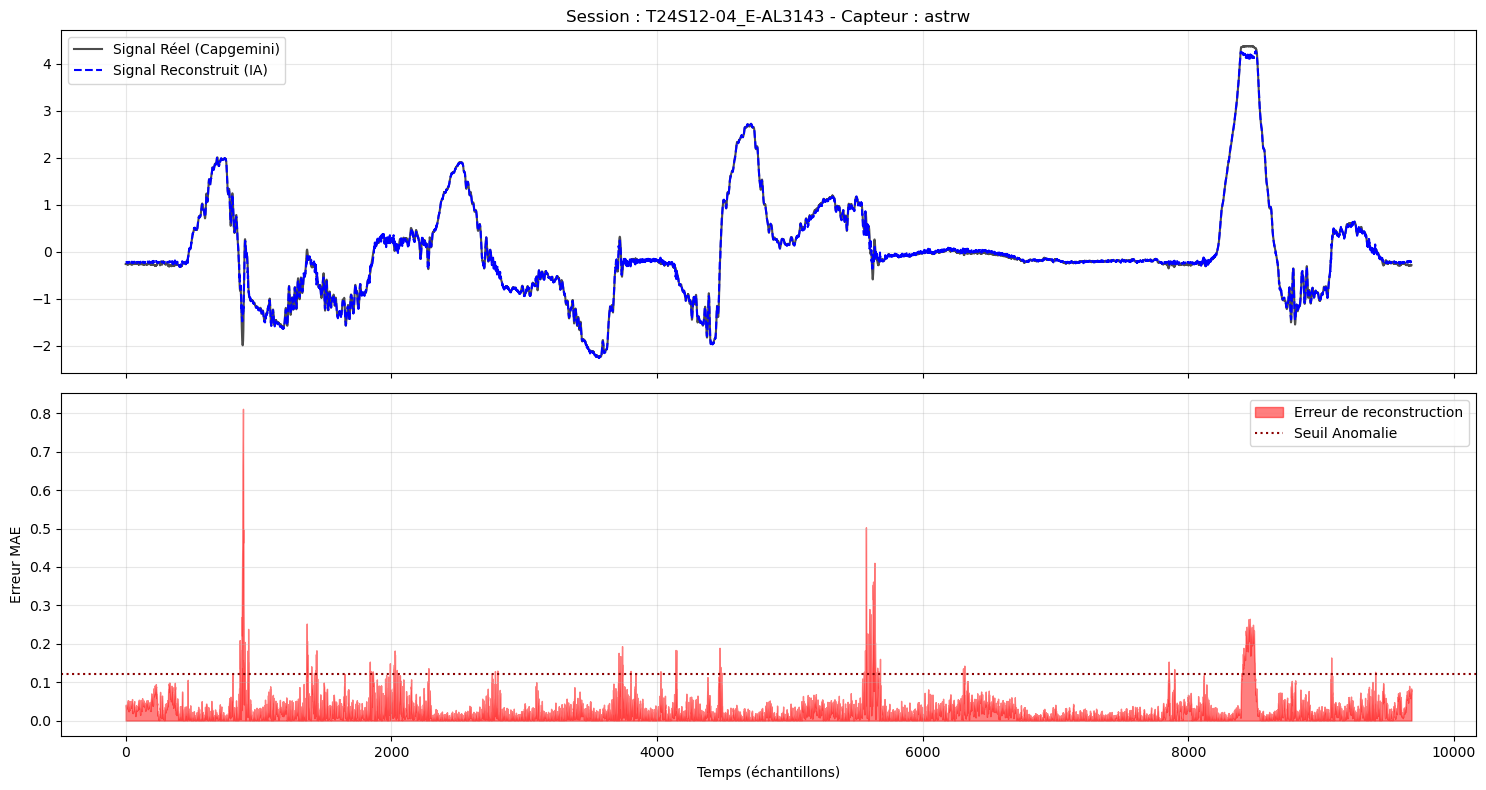

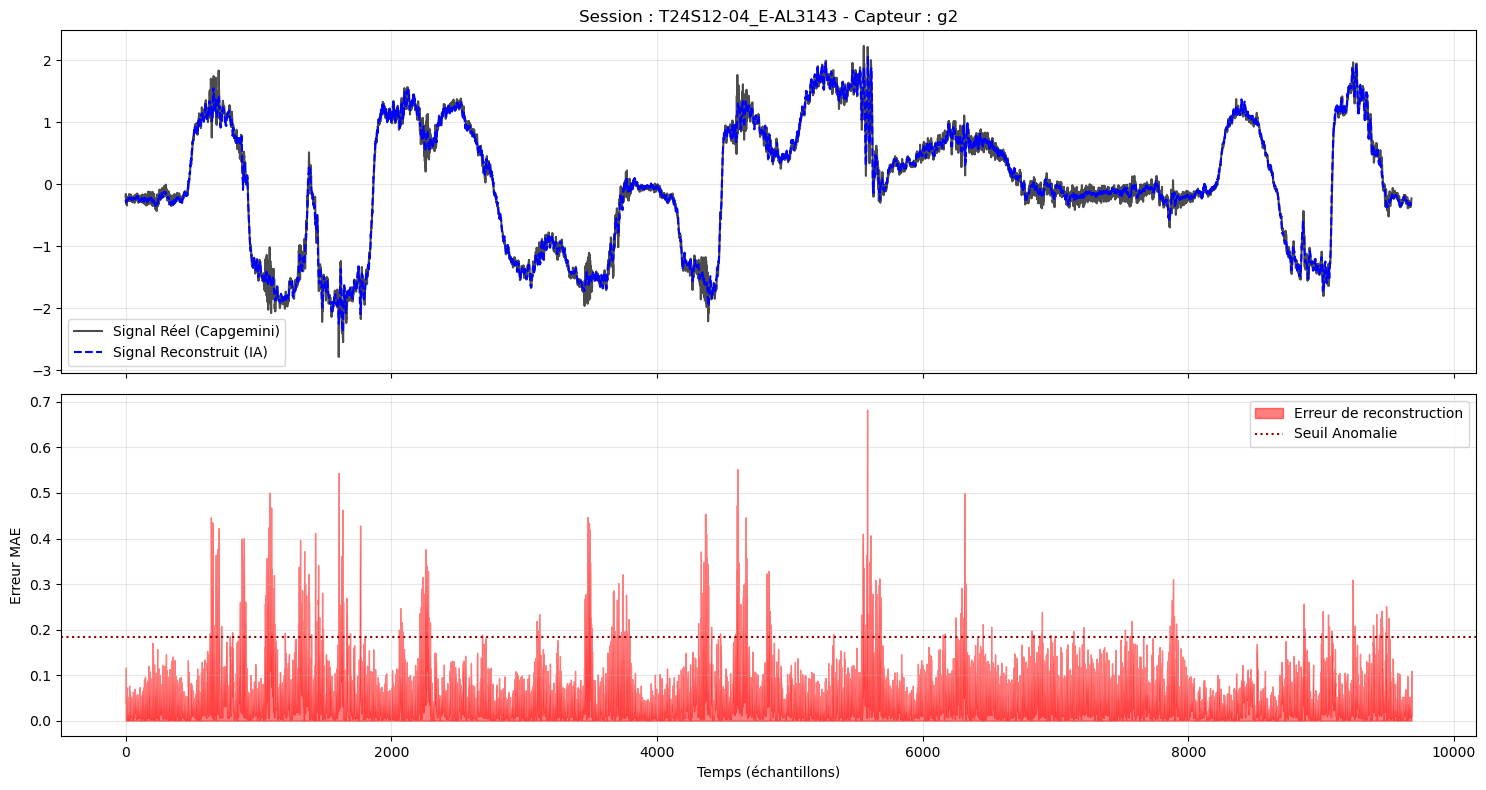

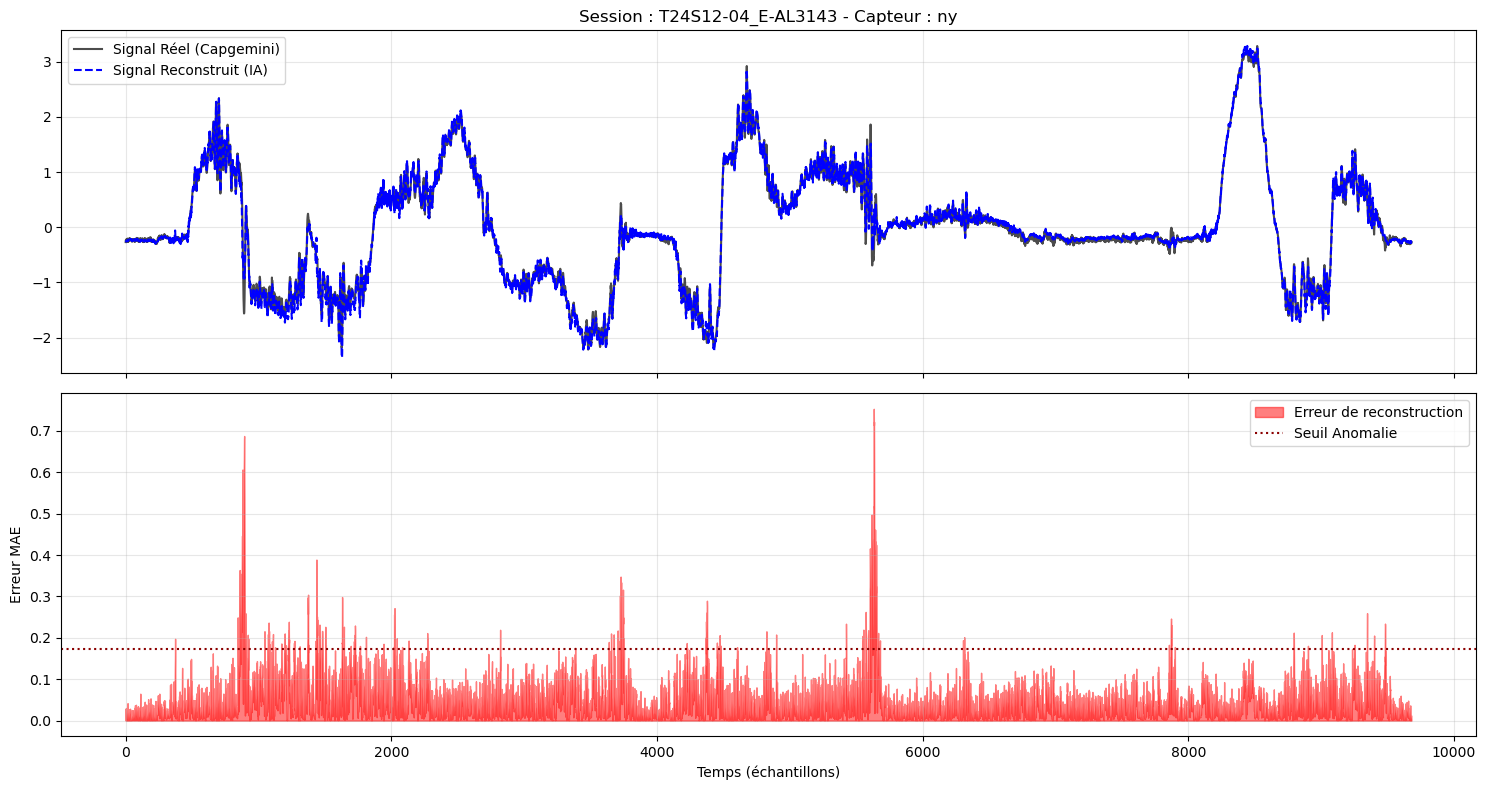

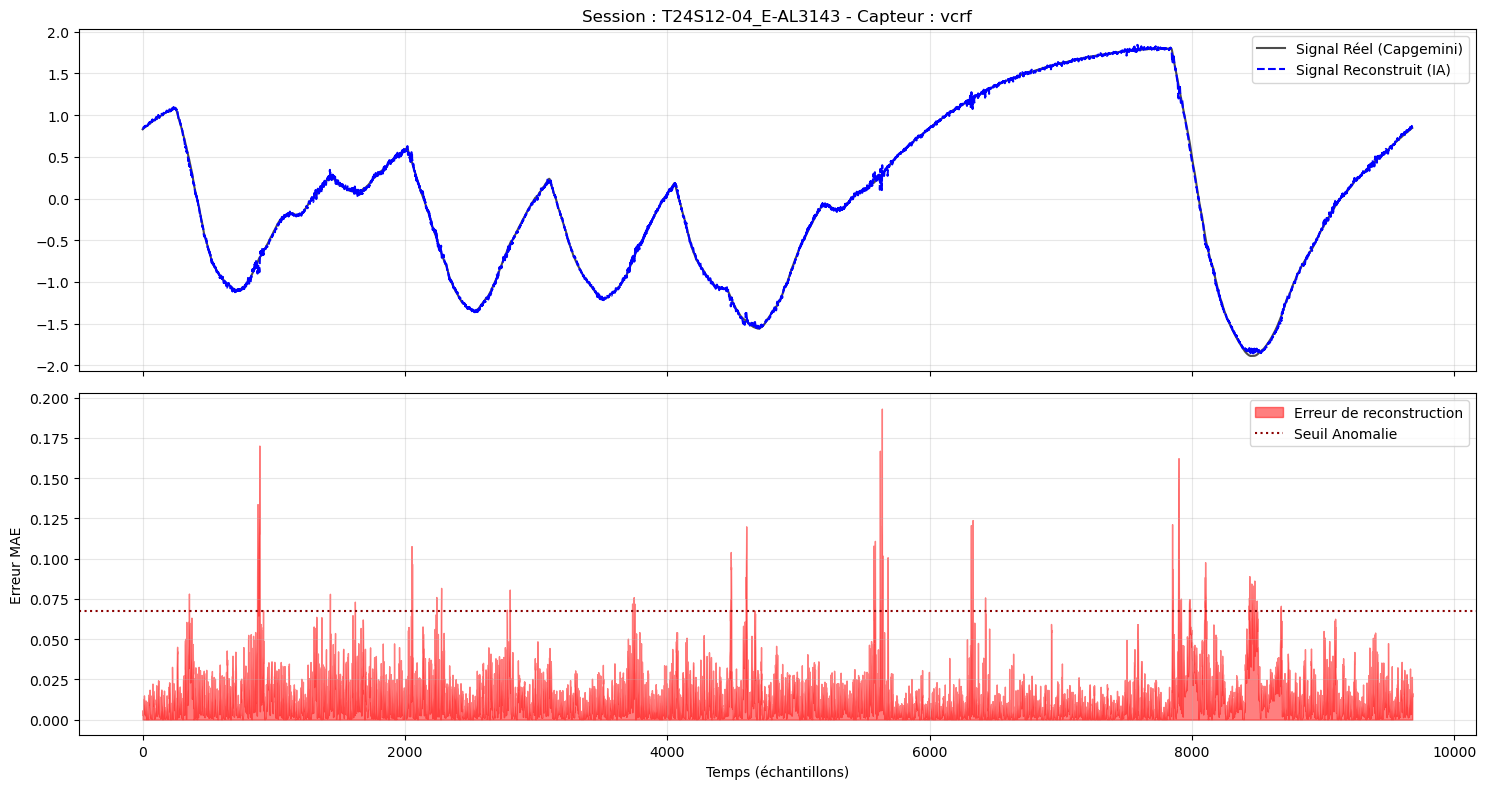

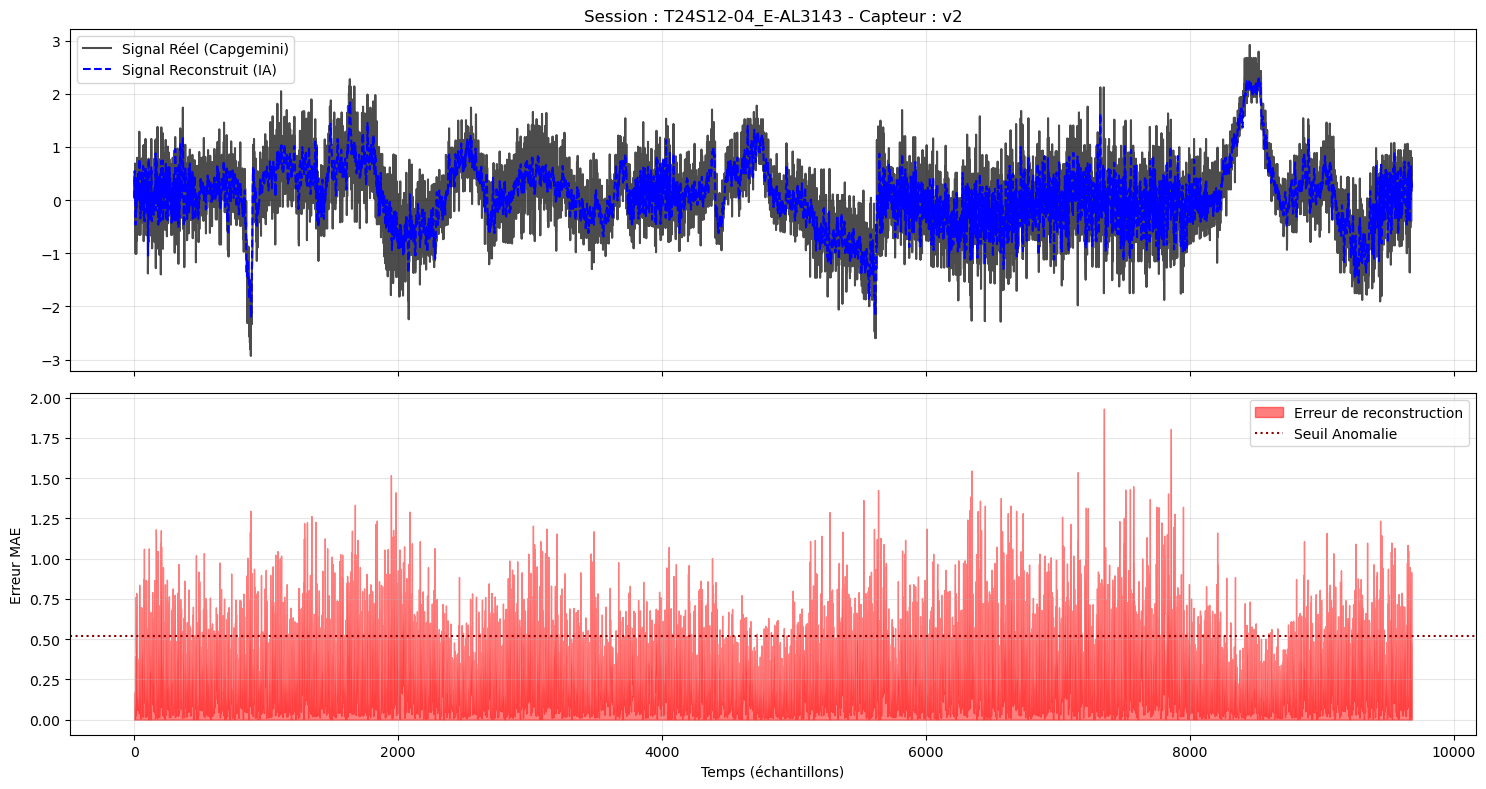

In [29]:
#On the whole session

session_test_id = df_test['session_id'].unique()[2] 
df_session = df_test[df_test['session_id'] == session_test_id]

# 2. On prépare les séquences pour cette session précise
x_session = create_sequences(df_session, features, TIME_STEPS)


x_session_pred = model_dnn.predict(x_session)

# 4. Reconstruction du signal continu
# On prend la dernière valeur de chaque fenêtre de 10 points
# Cela nous donne un signal qui suit exactement le signal original
for capteur_idx in range(15):
    signal_reel = x_session[:, 5, capteur_idx]
    signal_reconstruit = x_session_pred[:, 5, capteur_idx]#point au milieu de la fenêtre

    # 5. Calcul de l'erreur locale (MAE) pour l'affichage
    erreur_locale = np.abs(signal_reel - signal_reconstruit)

    # --- AFFICHAGE ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

    # Graphique du haut : Comparaison
    ax1.plot(signal_reel, label='Signal Réel (Capgemini)', color='black', alpha=0.7)
    ax1.plot(signal_reconstruit, label='Signal Reconstruit (IA)', color='blue', linestyle='--')
    ax1.set_title(f"Session : {session_test_id} - Capteur : {features[capteur_idx]}")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Graphique du bas : L'erreur (Le résidu)
    ax2.fill_between(range(len(erreur_locale)), erreur_locale, color='red', alpha=0.5, label='Erreur de reconstruction')
    # On peut même tracer le seuil calculé par ton camarade !
    ax2.axhline(y=seuils_dynamiques[capteur_idx], color='darkred', linestyle=':', label='Seuil Anomalie')
    ax2.set_ylabel("Erreur MAE")
    ax2.set_xlabel("Temps (échantillons)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [30]:
def calculate_persistent_anomalies(errors, threshold, persistence=5):
    """Compte les points en anomalie seulement si la condition persiste."""
    is_above = errors > threshold
    # Utilisation d'une fenêtre glissante pour vérifier la persistance
    # On vérifie si la somme des dépassements sur 5 points est égale à 5
    persistent_mask = np.convolve(is_above, np.ones(persistence), mode='valid') == persistence
    
    # On rajoute des zéros au début pour retrouver la taille originale du signal
    full_mask = np.concatenate([np.zeros(persistence-1), persistent_mask])
    return np.sum(full_mask > 0)


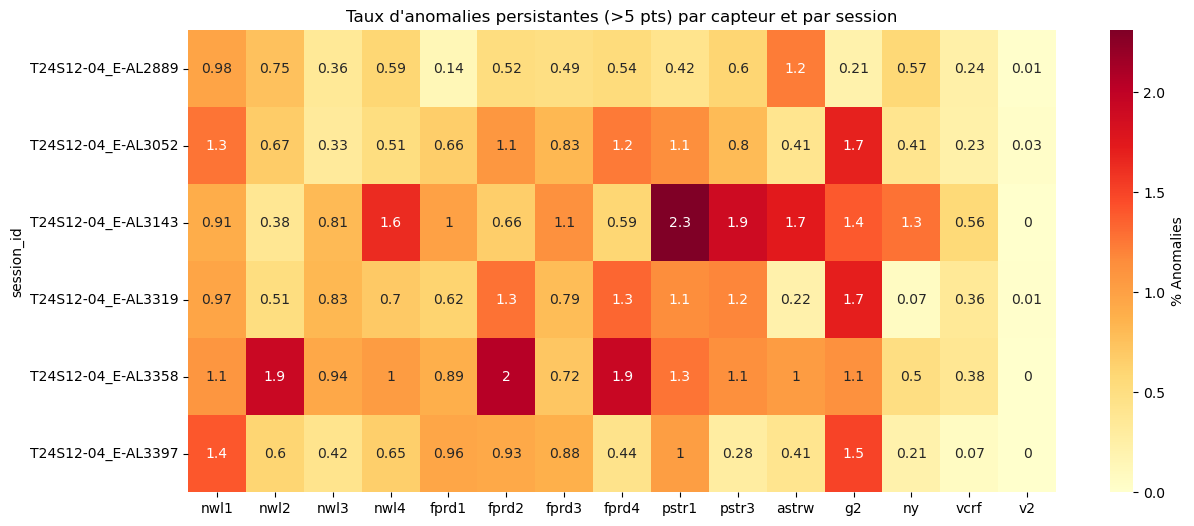

In [33]:
# Initialisation d'une liste pour stocker les résultats
results = []
sessions_test = df_test['session_id'].unique()[:]

for session_id in sessions_test:
    df_session = df_test[df_test['session_id'] == session_id]
    x_session = create_sequences(df_session, features, TIME_STEPS)
    x_pred = model_dnn.predict(x_session, verbose=0)
    
    # Calcul de l'erreur MAE (moyenne sur le temps) -> (N_sequences, 15)
    mae_session = np.mean(np.abs(x_pred - x_session), axis=1)
    
    session_report = {'session_id': session_id}
    
    for i, col in enumerate(features):
        # On récupère le seuil calculé sur le Train pour ce capteur
        thresh = seuils_dynamiques[i]
        
        # Calcul du nombre d'anomalies persistantes
        count = calculate_persistent_anomalies(mae_session[:, i], thresh, persistence=5)
        
        # Taux en %
        rate = (count / len(mae_session)) * 100
        session_report[col] = round(rate, 2)
        
    results.append(session_report)

# Création du tableau de synthèse
df_anomaly_report = pd.DataFrame(results).set_index('session_id')

# Affichage du tableau (heatmap pour voir les corrélations)
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.heatmap(df_anomaly_report, annot=True, cmap='YlOrRd', cbar_kws={'label': '% Anomalies'})
plt.title("Taux d'anomalies persistantes (>5 pts) par capteur et par session")
plt.show()

In [34]:
def get_anomaly_report(df_input, model, features, thresholds, persistence=5, time_steps=10):
    """
    Calcule le taux d'anomalies persistantes pour chaque session du dataframe.
    """
    results = []
    sessions = df_input['session_id'].unique()
    
    for session_id in sessions:
        df_session = df_input[df_input['session_id'] == session_id]
        
        # 1. Création des séquences
        x_session = create_sequences(df_session, features, time_steps)
        if len(x_session) == 0: continue # Sécurité session trop courte
        
        # 2. Prédiction (Inférence)
        x_pred = model.predict(x_session, verbose=0)
        
        # 3. Calcul de l'erreur MAE point par point (on garde le milieu : index 5)
        # On compare le point réel au milieu et sa reconstruction au milieu
        mid_idx = time_steps // 2
        errors = np.abs(x_pred[:, mid_idx, :] - x_session[:, mid_idx, :])
        
        session_report = {'session_id': session_id}
        
        for i, col in enumerate(features):
            # Calcul de la persistance sur l'erreur du capteur i
            is_above = errors[:, i] > thresholds[i]
            persistent_mask = np.convolve(is_above.astype(int), np.ones(persistence), mode='valid') == persistence
            count = np.sum(persistent_mask)
            
            # Taux en %
            rate = (count / len(errors)) * 100
            session_report[col] = round(rate, 2)
            
        results.append(session_report)
    
    return pd.DataFrame(results).set_index('session_id')

def plot_anomaly_heatmap(df_report, title="Analyse des Anomalies"):
    """
    Affiche la heatmap à partir d'un rapport d'anomalies.
    """
    plt.figure(figsize=(15, 7))
    sns.heatmap(df_report, annot=True, cmap='YlOrRd', fmt=".1f", cbar_kws={'label': '% Anomalies'})
    plt.title(title)
    plt.ylabel("Session ID")
    plt.xlabel("Capteurs")
    plt.xticks(rotation=45)
    plt.show()


Sessions anormales prêtes. Dimensions : (323060, 18)
Nombre de sessions anormales identifiées : 10


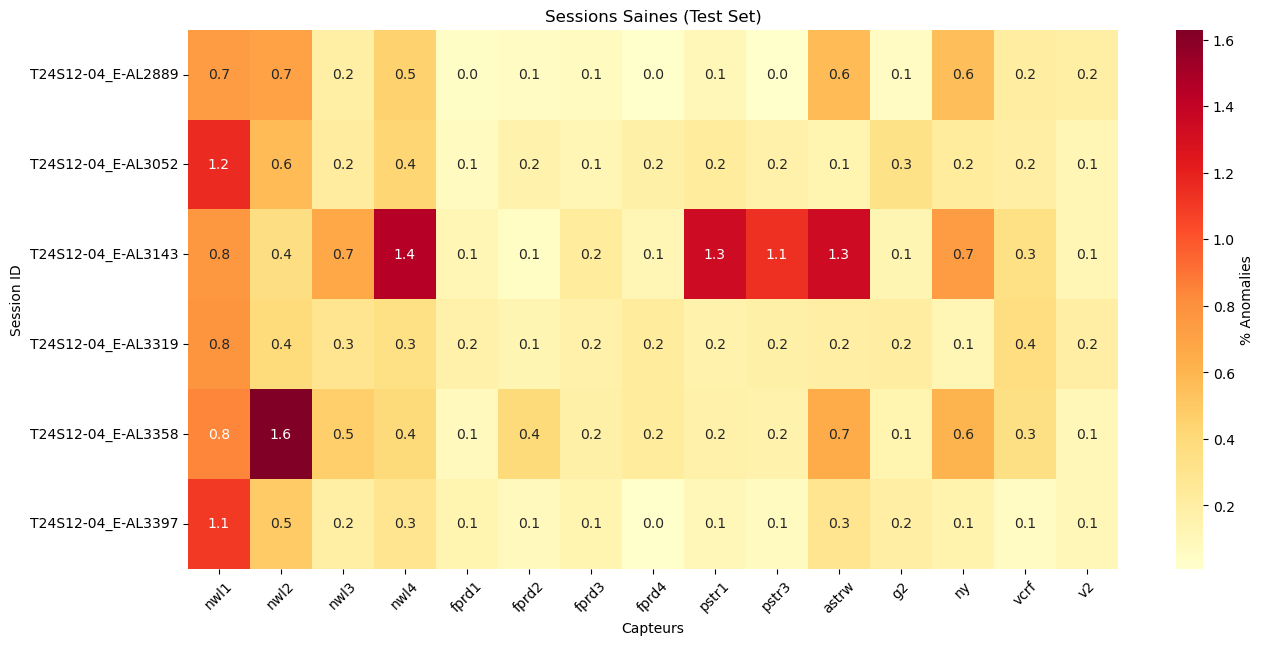

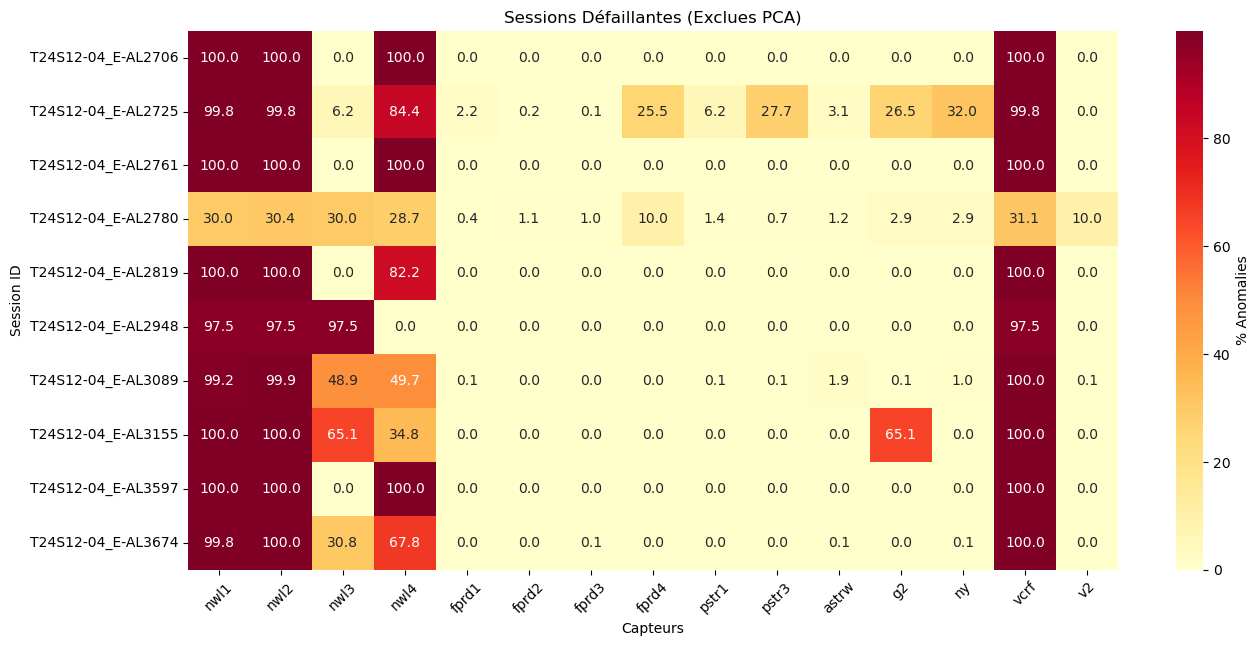

In [35]:
# On crée une liste pour stocker les DataFrames des sessions rejetées par la PCA
df_anormal_list = []

# On parcourt uniquement les sessions qui sont dans ta liste 'session_anomaly'
for cle in list_keys:
    session_name = os.path.splitext(os.path.basename(cle))[0]
    
    if session_name in session_anomaly:
        df_temp = data_dict[cle].copy()
        # On applique le même nettoyage que pour les sessions saines
        df_temp = preprocessing.clean_dataframe(df_temp)
        
        if df_temp.shape[0] > 0:
            if 'session_id' not in df_temp.columns:
                df_temp['session_id'] = session_name
            df_anormal_list.append(df_temp)

# On fusionne tout
df_anormal = pd.concat(df_anormal_list, ignore_index=True)

# IMPORTANT : On applique le scaler ajusté sur le TRAIN
# On ne fait pas de fit(), seulement transform()
df_anormal[features] = scaler.transform(df_anormal[features])

print(f"Sessions anormales prêtes. Dimensions : {df_anormal.shape}")
print(f"Nombre de sessions anormales identifiées : {df_anormal['session_id'].nunique()}")

# 2. Lancer les rapports
report_sain = get_anomaly_report(df_test, model_dnn, features, seuils_dynamiques)
report_anormal = get_anomaly_report(df_anormal, model_dnn, features, seuils_dynamiques)

# 3. Afficher les heatmaps
plot_anomaly_heatmap(report_sain, title="Sessions Saines (Test Set)")
plot_anomaly_heatmap(report_anormal, title="Sessions Défaillantes (Exclues PCA)")

# Save the model

In [ ]:
import os
import joblib
from tensorflow.keras.models import load_model

# 1. Créer le dossier s'il n'existe pas
if not os.path.exists('models'):
    os.makedirs('models')

# 2. Sauvegarder le modèle (architecture + poids)
model_dnn.save('models/DNN_autoencoder.keras')

# 3. Sauvegarder le scaler (indispensable pour les futures prédictions)
joblib.dump(scaler, 'models/scaler_DNN_autoencoder.pkl')



Modèle et Scaler sauvegardés dans le dossier 'models/' !


In [38]:
#to call the model and the scaler do
# model = load_model('models/DNN_autoencoder.keras')
# scaler = joblib.load('models/scaler_autoencoder.pkl') 